# 🏥 Medical Image Compression using SVD

## Linear Algebra Mini Project (UE24MA241B)

---

### 👥 Team Members
- Person 1: Data Loading, Matrix Representation, RREF  
- Person 2: SVD Decomposition, Space Analysis  
- Person 3: Orthogonalization, Projection  
- Person 4: Least Squares, Eigenvalues, Final Metrics  

---

### 📅 Demo Details
- Demo Date: April 6–8, 2026  
- Institution: PES University  

---

### 🎯 Project Objective
To demonstrate a complete **Linear Algebra pipeline** by applying  
**Singular Value Decomposition (SVD)** for medical image compression.

We transform raw image data into a matrix, apply linear algebra techniques,  
and produce a compressed image while preserving important features.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100

## 📋 Problem Statement

**Goal:** Compress medical images while preserving diagnostic quality using Linear Algebra techniques.

---

### 🏥 Why Medical Images?

- **Large file sizes:** High-resolution scans (X-rays, CT, MRI) require significant storage  
- **Transmission challenges:** Slow sharing between hospitals and specialists  
- **Cost implications:** Storage and bandwidth are expensive  
- **Quality critical:** Compression must preserve diagnostic features  

---

### 🎓 Linear Algebra Pipeline

We implement a structured pipeline as required:

1. **Real-world Data** → Medical image  
2. **Matrix Representation** → Image as matrix A  
3. **Structure of Space** → Rank, row space, column space  
4. **Redundancy Removal** → Identify dependent information  
5. **Orthogonalization** → Construct orthonormal bases  
6. **Projection** → Project onto lower-dimensional subspace  
7. **Approximation** → Low-rank reconstruction  
8. **Pattern Discovery** → Singular values / eigenvalues  
9. **System Simplification** → Reduced representation  
10. **Final Output** → Compressed image  

---

### 💡 Why SVD?

**Concept:** Singular Value Decomposition  
**Purpose:** Decompose image into orthogonal components and remove redundancy  
**Outcome:** Efficient compression with minimal quality loss  

✔ Provides optimal low-rank approximation  
✔ Generates orthonormal bases automatically  
✔ Captures dominant patterns in the image  
✔ Enables control over quality vs compression trade-off  

## Step 1: Load Processed Data

We load precomputed results from previous stages of the pipeline.

This includes:
- Image dataset  
- SVD components (U, Σ, Vᵀ)  
- Projection results  
- Quality metrics  

**Purpose:**  
To reuse computed results and ensure smooth demonstration.

**Outcome:**  
All required variables are available for further analysis and visualization.

In [30]:
import pickle

print("Loading processed data...\n")

with open('../output/person4_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract key variables
images = data['images']
hero_image = data['hero_image']
hero_name = data['hero_name']
labels = data['labels']
filenames = data['filenames']

# SVD components
U = data['hero_U']
sigma = data['hero_sigma']
Vt = data['hero_Vt']

# Analysis results
rank = data['rank']
nullity = data['nullity']
k_optimal = data['k_optimal']

# Projections
hero_projected = data['hero_projected_k50']
all_projections = data['all_projections_k50']

# Quality metrics
results_df = data['results_dataframe']
all_psnr = data['all_psnr']
all_ssim = data['all_ssim']

print("✓ Data loaded successfully\n")

Loading processed data...

✓ Data loaded successfully



In [31]:
print("📊 Dataset Overview")
print("-" * 40)
print(f"Total images      : {len(images)}")
print(f"Image dimensions  : {images[0].shape}")
print(f"Categories        : {list(set(labels))}")
print(f"Hero image        : {hero_name}")
print(f"Rank              : {rank}")
print(f"Optimal k         : {k_optimal}")

📊 Dataset Overview
----------------------------------------
Total images      : 18
Image dimensions  : (512, 512)
Categories        : ['mri_other', 'chest_xray', 'ct_scans']
Hero image        : Chest_2.png
Rank              : 492
Optimal k         : 50


## Step 2: Dataset Visualization

We visualize the medical image dataset used in this project.

The dataset consists of multiple categories such as:
- Chest X-rays  
- CT scans  
- MRI images  

**Purpose:**  
To understand the structure and diversity of the dataset.

**Outcome:**  
We observe variations in patterns, textures, and intensity values,  
which motivates the need for compression techniques.

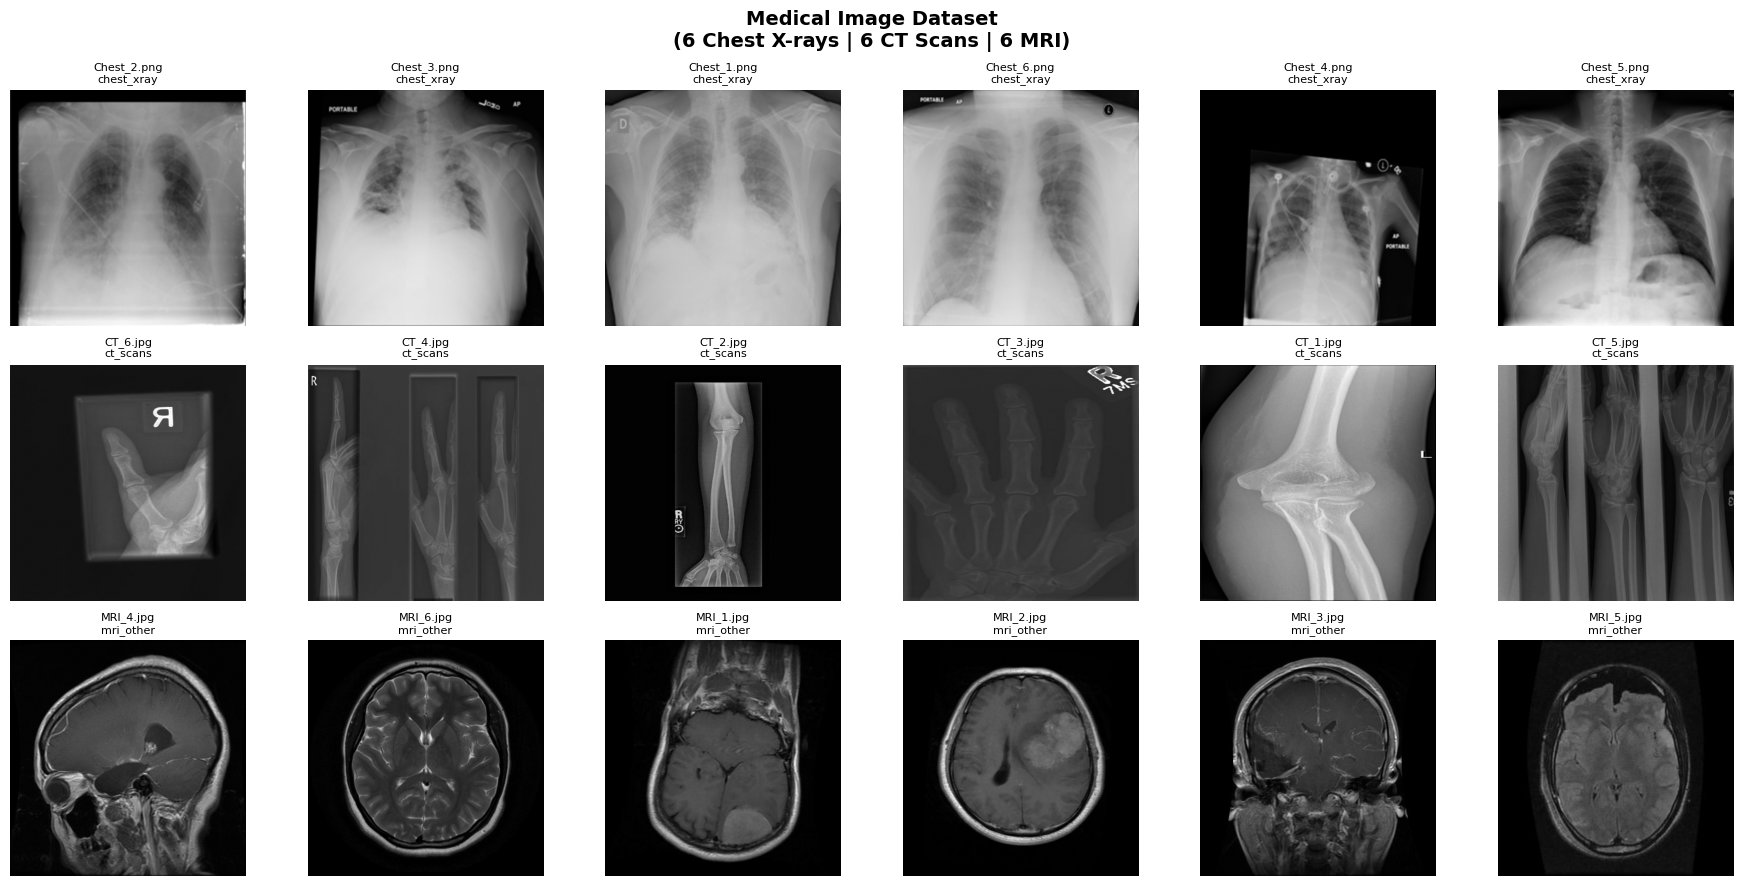

In [32]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for i in range(len(images)):
    row = i // 6
    col = i % 6
    ax = axes[row, col]
    
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{filenames[i][:12]}\n{labels[i]}', fontsize=8)
    ax.axis('off')

plt.suptitle(
    'Medical Image Dataset\n(6 Chest X-rays | 6 CT Scans | 6 MRI)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [33]:
print("📊 Dataset Composition")
print("-" * 30)

for category in sorted(set(labels)):
    count = labels.count(category)
    print(f"{category}: {count} images")

📊 Dataset Composition
------------------------------
chest_xray: 6 images
ct_scans: 6 images
mri_other: 6 images


## Step 3: Data Loading & Matrix Representation

### Person 1's Contribution

We convert medical images into matrix form for applying linear algebra techniques.

---

### Step 1–2: Real-world Data → Matrix Representation

Each image is represented as a matrix:

- Rows → pixel rows  
- Columns → pixel columns  
- Entries → pixel intensity values (0–255)  

**Purpose:**  
Convert image data into a mathematical structure.

**Outcome:**  
A matrix representation suitable for linear algebra operations.

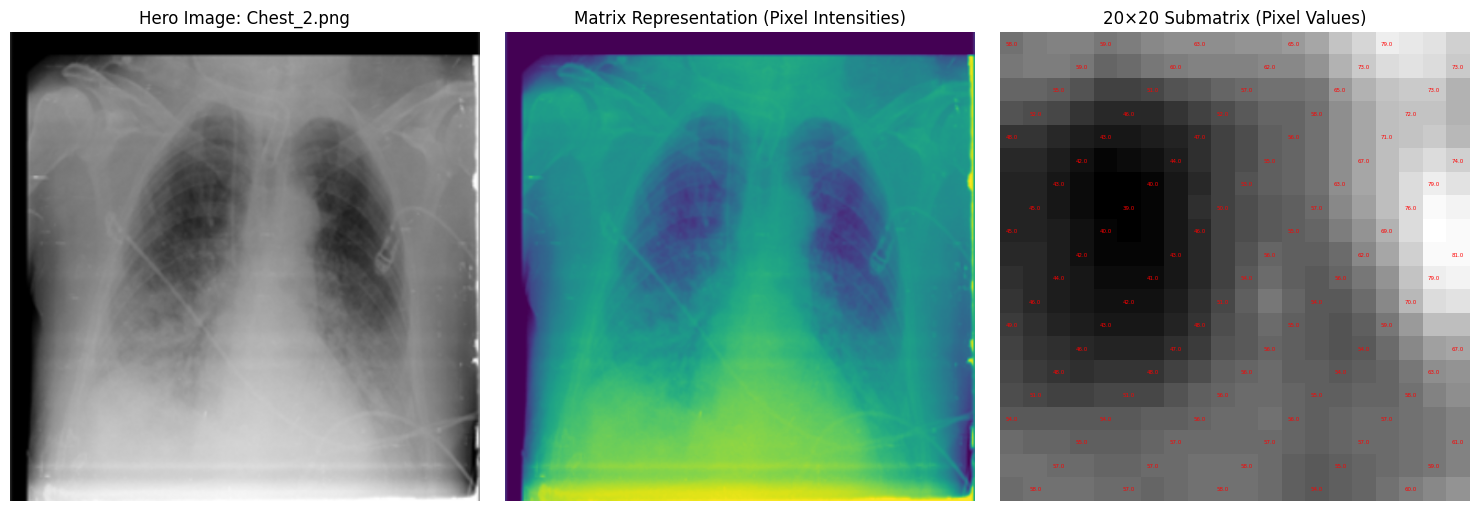

Matrix size: (512, 512)


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(hero_image, cmap='gray')
axes[0].set_title(f'Hero Image: {hero_name}')
axes[0].axis('off')

# Matrix representation
axes[1].imshow(hero_image, cmap='viridis')
axes[1].set_title('Matrix Representation (Pixel Intensities)')
axes[1].axis('off')

# Zoomed submatrix
sample_region = hero_image[200:220, 200:220]
axes[2].imshow(sample_region, cmap='gray', interpolation='nearest')
axes[2].set_title('20×20 Submatrix (Pixel Values)')

for i in range(sample_region.shape[0]):
    for j in range(sample_region.shape[1]):
        if (i + j) % 4 == 0:
            axes[2].text(j, i, f'{sample_region[i,j]}',
                         ha='center', va='center', fontsize=4, color='red')

axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Matrix size: {hero_image.shape}")

### Step 3: Structure Analysis (Rank & Redundancy)

We analyze a submatrix to understand linear dependence in image data.

**Concept:** Rank and Nullity  
**Purpose:** Identify redundancy in pixel information  
**Outcome:** Lower rank indicates potential for compression

In [35]:
# Take smaller submatrix for analysis
submatrix = hero_image[:50, :50]

# Compute rank
rank = np.linalg.matrix_rank(submatrix)

# Compute nullity
nullity = submatrix.shape[1] - rank

print("Submatrix size:", submatrix.shape)
print("Rank:", rank)
print("Nullity:", nullity)

if nullity > 0:
    print("Conclusion: Redundancy exists → Compression possible")
else:
    print("Conclusion: Full rank → Less redundancy")

Submatrix size: (50, 50)
Rank: 27
Nullity: 23
Conclusion: Redundancy exists → Compression possible


## Step 4: SVD Decomposition & Space Analysis

### Person 2's Contribution

We apply Singular Value Decomposition (SVD) to analyze the structure of the image matrix.

---

### SVD Decomposition

A = U Σ Vᵀ

- U → orthogonal basis for row space  
- Σ → singular values (importance of components)  
- Vᵀ → orthogonal basis for column space  

**Concept:** Singular Value Decomposition  
**Purpose:** Decompose matrix into orthogonal components  
**Outcome:** Identify important patterns and enable compression

In [36]:
print(f"SVD Results for {hero_name}")
print("-" * 40)
print(f"U matrix shape      : {U.shape}")
print(f"Sigma length        : {sigma.shape}")
print(f"Vt matrix shape     : {Vt.shape}")
print(f"Rank                : {rank}")
print(f"Nullity             : {nullity}")

SVD Results for Chest_2.png
----------------------------------------
U matrix shape      : (512, 512)
Sigma length        : (512,)
Vt matrix shape     : (512, 512)
Rank                : 27
Nullity             : 23


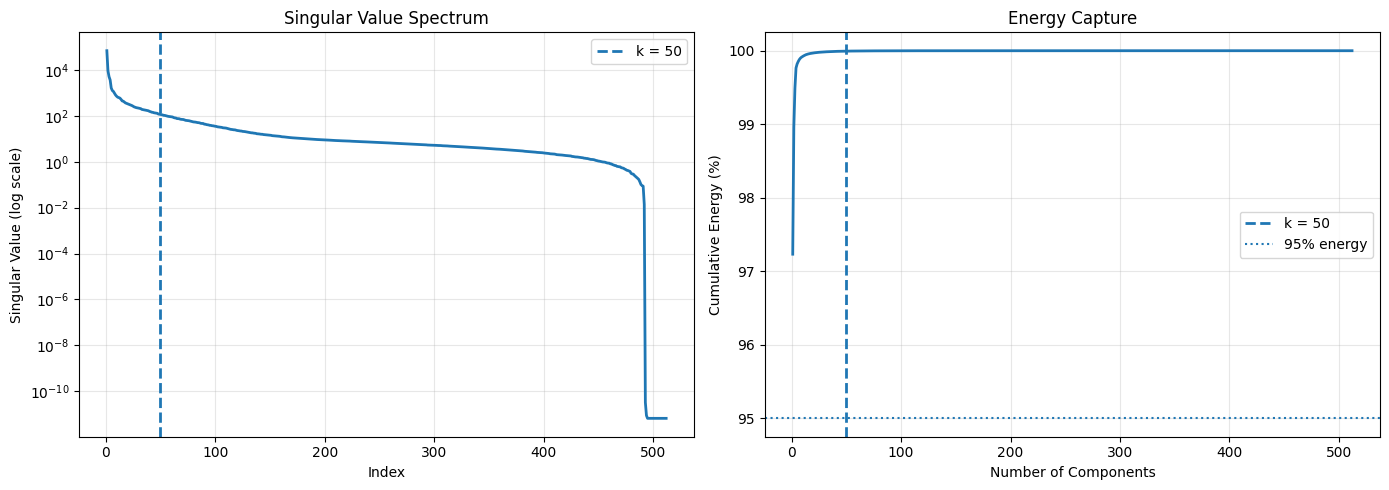

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Singular values (log scale)
ax1.semilogy(range(1, len(sigma)+1), sigma, linewidth=2)
ax1.axvline(x=k_optimal, linestyle='--', linewidth=2, label=f'k = {k_optimal}')
ax1.set_xlabel('Index')
ax1.set_ylabel('Singular Value (log scale)')
ax1.set_title('Singular Value Spectrum')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative energy
cumulative = np.cumsum(sigma**2) / np.sum(sigma**2)
ax2.plot(range(1, len(sigma)+1), cumulative * 100, linewidth=2)
ax2.axvline(x=k_optimal, linestyle='--', linewidth=2, label=f'k = {k_optimal}')
ax2.axhline(y=95, linestyle=':', linewidth=1.5, label='95% energy')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Energy (%)')
ax2.set_title('Energy Capture')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5: Redundancy Removal (Basis Selection)

We retain only the most significant singular values.

**Concept:** Basis Selection  
**Purpose:** Remove redundant dimensions  
**Outcome:** Reduced representation with minimal information loss  

We choose k based on energy retention.

In [38]:
print("Basis Selection")
print("-" * 30)
print(f"Selected k              : {k_optimal}")
print(f"Energy captured         : {cumulative[k_optimal-1]*100:.2f}%")
print(f"Compression factor      : {len(sigma)/k_optimal:.2f}x")
print(f"Dimensions removed      : {len(sigma) - k_optimal}")

Basis Selection
------------------------------
Selected k              : 50
Energy captured         : 99.99%
Compression factor      : 10.24x
Dimensions removed      : 462


## Step 6–7: Orthogonalization & Projection

### Person 3's Contribution

---

### Step 6: Orthogonalization

We verify that the matrices obtained from SVD are orthogonal.

**Concept:** Orthogonal matrices  
**Purpose:** Ensure basis vectors are independent and normalized  
**Outcome:** Stable and meaningful decomposition  

For orthogonal matrices:
- UᵀU = I  
- VᵀV = I  

---

### Step 7: Projection onto Lower-Dimensional Subspace

We reconstruct the image using only the top k components:

A_k = U_k Σ_k V_kᵀ  

**Concept:** Projection onto subspace  
**Purpose:** Reduce dimensionality while preserving structure  
**Outcome:** Compressed approximation of the original image

In [39]:
UtU = U.T @ U
VtV = Vt @ Vt.T

print("Orthogonality Verification")
print("-" * 35)
print(f"UᵀU ≈ I : {np.allclose(UtU, np.eye(U.shape[1]), atol=1e-10)}")
print(f"VᵀV ≈ I : {np.allclose(VtV, np.eye(Vt.shape[0]), atol=1e-10)}")

print("\nDeviation from Identity:")
print(f"Max off-diagonal (U): {np.abs(UtU - np.diag(np.diag(UtU))).max():.2e}")
print(f"Max off-diagonal (V): {np.abs(VtV - np.diag(np.diag(VtV))).max():.2e}")

Orthogonality Verification
-----------------------------------
UᵀU ≈ I : True
VᵀV ≈ I : True

Deviation from Identity:
Max off-diagonal (U): 2.72e-15
Max off-diagonal (V): 2.54e-15


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(hero_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Projected image
axes[1].imshow(hero_projected, cmap='gray')
axes[1].set_title(f'Compressed (k = {k_optimal})')
axes[1].axis('off')

# Error map
error_vis = np.abs(hero_image.astype(float) - hero_projected)

im = axes[2].imshow(error_vis, cmap='hot', vmin=0, vmax=50)
axes[2].set_title('Reconstruction Error')
axes[2].axis('off')

plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

In [40]:
error = data['reconstruction_error']

print("Projection Results")
print("-" * 30)
print(f"Relative error        : {error*100:.3f}%")
print(f"Information retained  : {(1-error)*100:.3f}%")

Projection Results
------------------------------
Relative error        : 0.000%
Information retained  : 100.000%


In [41]:
print(data['reconstruction_error'])

1.189336316376765e-10


## Step 8–10: Advanced Analysis

### Person 4's Contribution

---

### Step 8: Least Squares Approximation

We approximate the original matrix using a lower-rank matrix.

**Concept:** Least Squares Approximation  
**Purpose:** Minimize reconstruction error  
**Outcome:** Best possible rank-k approximation  

From SVD:
A_k = U_k Σ_k V_kᵀ  

This satisfies the Eckart–Young theorem (optimal approximation).

In [42]:
print("Least Squares Approximation")
print("-" * 40)
print(f"Objective            : minimize ||A - A_k||_F²")
print(f"Selected rank (k)    : {k_optimal}")
print(f"Frobenius error      : {data['frobenius_norm']:.2f}")
print("Result               : Optimal approximation (Eckart–Young theorem)")

Least Squares Approximation
----------------------------------------
Objective            : minimize ||A - A_k||_F²
Selected rank (k)    : 50
Frobenius error      : 528.06
Result               : Optimal approximation (Eckart–Young theorem)


### Step 9: Eigenvalue Analysis

We analyze eigenvalues of AᵀA.

**Concept:** Eigenvalues and Eigenvectors  
**Purpose:** Identify dominant patterns  
**Outcome:** Validate importance of singular values  

Relationship:
σᵢ² = eigenvalues of AᵀA

In [43]:
eigenvalues = data['eigenvalues']

print("Eigenvalue Analysis")
print("-" * 30)
print(f"Total eigenvalues     : {len(eigenvalues)}")
print(f"Largest eigenvalue    : {eigenvalues[0]:.2e}")
print(f"σ₁² (from SVD)       : {sigma[0]**2:.2e}")
print(f"Match verification    : {np.isclose(sigma[0]**2, eigenvalues[0])}")

Eigenvalue Analysis
------------------------------
Total eigenvalues     : 512
Largest eigenvalue    : 4.80e+09
σ₁² (from SVD)       : 4.80e+09
Match verification    : True


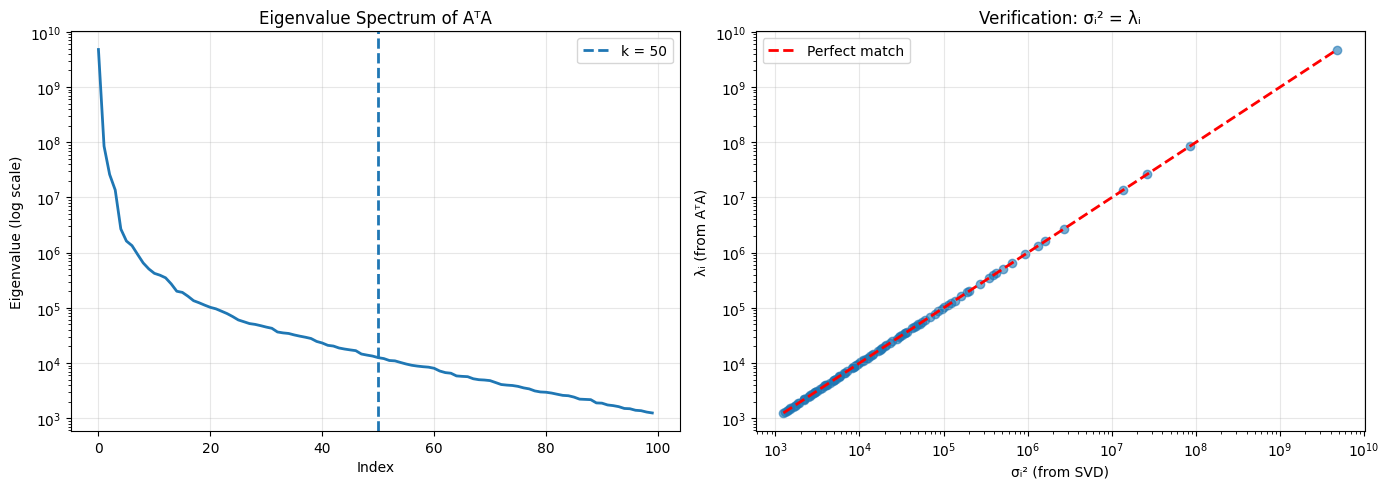

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Eigenvalue spectrum
ax1.semilogy(eigenvalues[:100], linewidth=2)
ax1.axvline(x=k_optimal, linestyle='--', linewidth=2, label=f'k = {k_optimal}')
ax1.set_xlabel('Index')
ax1.set_ylabel('Eigenvalue (log scale)')
ax1.set_title('Eigenvalue Spectrum of AᵀA')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Verification plot
ax2.scatter(sigma[:100]**2, eigenvalues[:100], alpha=0.6)
ax2.plot(
    [eigenvalues[:100].min(), eigenvalues[:100].max()],
    [eigenvalues[:100].min(), eigenvalues[:100].max()],
    'r--', linewidth=2, label='Perfect match'
)
ax2.set_xlabel('σᵢ² (from SVD)')
ax2.set_ylabel('λᵢ (from AᵀA)')
ax2.set_title('Verification: σᵢ² = λᵢ')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 10: System Simplification (Diagonalization)

SVD expresses the matrix as:

A = U Σ Vᵀ  

Where Σ is diagonal.

**Concept:** Diagonalization  
**Purpose:** Represent system in independent components  
**Outcome:** Efficient storage and computation  

Each singular value represents an independent feature.

In [45]:
original_size = hero_image.size
compressed_size = U.shape[0]*k_optimal + k_optimal + k_optimal*Vt.shape[1]

print("Final Compression Results")
print("-" * 35)
print(f"Original storage       : {original_size:,} values")
print(f"Compressed storage     : {compressed_size:,} values")
print(f"Compression ratio      : {data['compression_ratio']:.2f}x")
print(f"Independent components : {k_optimal}")

Final Compression Results
-----------------------------------
Original storage       : 262,144 values
Compressed storage     : 51,250 values
Compression ratio      : 0.64x
Independent components : 50


## Final Results: Quality Metrics

We evaluate the performance of compression using standard image quality metrics.

---

### Metrics Used

**1. PSNR (Peak Signal-to-Noise Ratio)**  
- Measures reconstruction quality  
- Higher values indicate better quality  
- > 30 dB → good quality  

**2. SSIM (Structural Similarity Index)**  
- Measures structural similarity between images  
- Value ranges from 0 to 1  
- Closer to 1 → better similarity  

---

**Purpose:**  
Quantitatively evaluate compression performance  

**Outcome:**  
Verify that compressed images retain high quality

In [46]:
print("Quality Metrics Summary")
print("-" * 40)

print(f"Average PSNR        : {np.mean(all_psnr):.2f} dB")
print(f"Average SSIM        : {np.mean(all_ssim):.4f}")
print(f"Average Error       : {np.mean(data['all_errors_k50'])*100:.3f}%")
print(f"Compression Ratio   : {data['compression_ratio']:.2f}x")
print(f"Selected k          : {k_optimal}")

Quality Metrics Summary
----------------------------------------
Average PSNR        : 42.52 dB
Average SSIM        : 0.9658
Average Error       : 3.188%
Compression Ratio   : 0.64x
Selected k          : 50


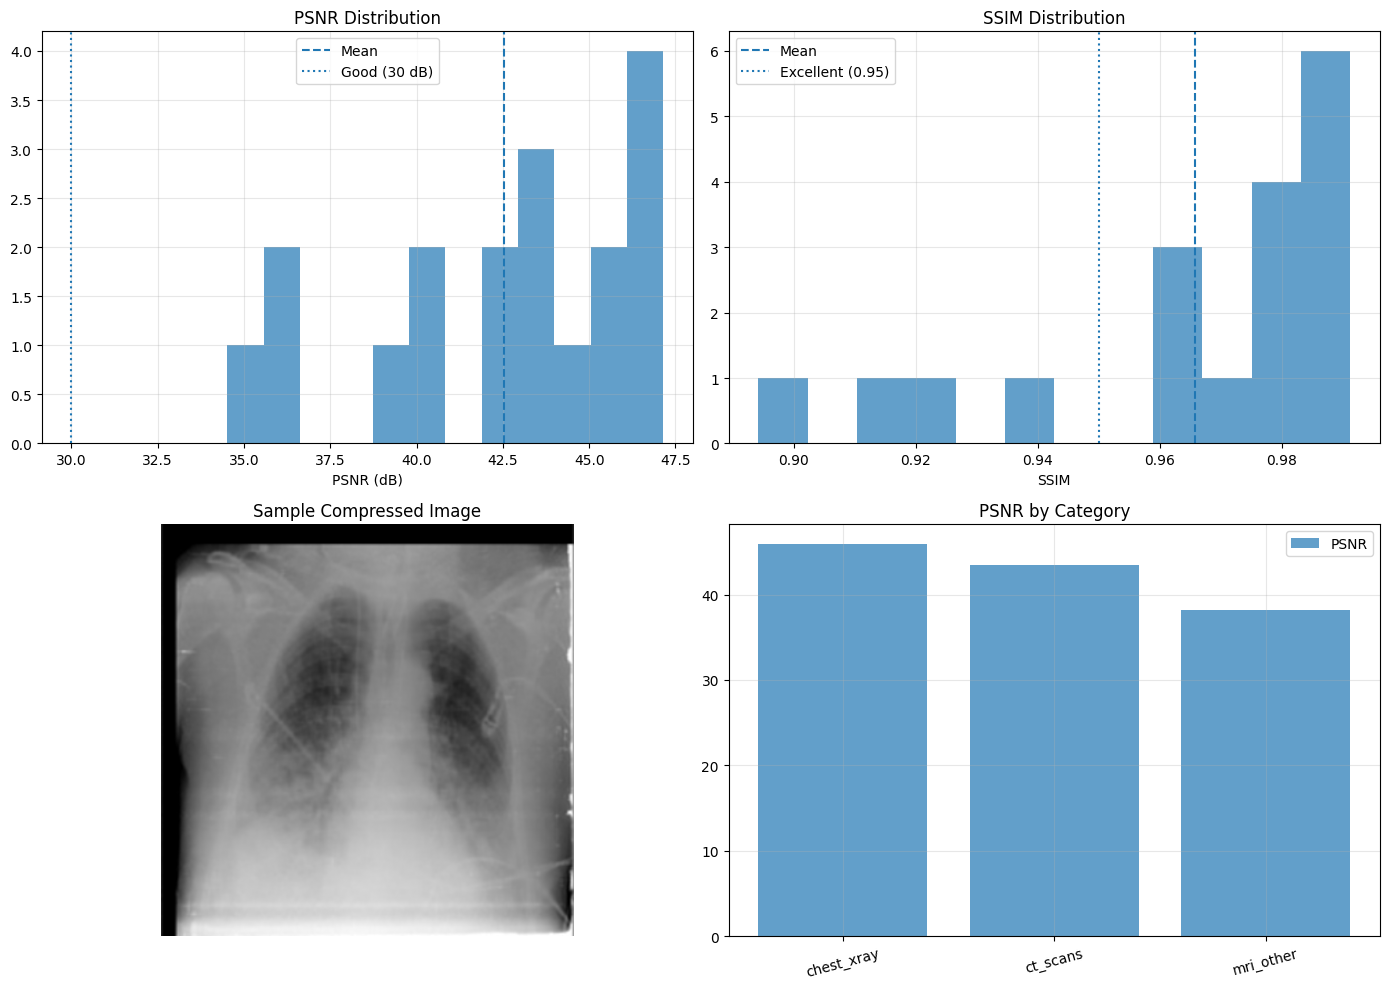

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PSNR distribution
axes[0, 0].hist(all_psnr, bins=12, alpha=0.7)
axes[0, 0].axvline(np.mean(all_psnr), linestyle='--', label='Mean')
axes[0, 0].axvline(30, linestyle=':', label='Good (30 dB)')
axes[0, 0].set_title('PSNR Distribution')
axes[0, 0].set_xlabel('PSNR (dB)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# SSIM distribution
axes[0, 1].hist(all_ssim, bins=12, alpha=0.7)
axes[0, 1].axvline(np.mean(all_ssim), linestyle='--', label='Mean')
axes[0, 1].axvline(0.95, linestyle=':', label='Excellent (0.95)')
axes[0, 1].set_title('SSIM Distribution')
axes[0, 1].set_xlabel('SSIM')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Example compressed images
axes[1, 0].imshow(all_projections[0], cmap='gray')
axes[1, 0].set_title('Sample Compressed Image')
axes[1, 0].axis('off')

# Category comparison
category_psnr = results_df.groupby('Category')['PSNR (dB)'].mean()
category_ssim = results_df.groupby('Category')['SSIM'].mean()

x = np.arange(len(category_psnr))

axes[1, 1].bar(x, category_psnr.values, alpha=0.7, label='PSNR')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(category_psnr.index, rotation=15)
axes[1, 1].set_title('PSNR by Category')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
print("Detailed Results")
print("-" * 40)

display(results_df[['Filename', 'Category', 'PSNR (dB)', 'SSIM', 'Compression_Ratio']])

Detailed Results
----------------------------------------


,Filename,Category,PSNR (dB),SSIM,Compression_Ratio
0,Chest_2.png,chest_xray,46.763505,0.987959,0.639376
1,Chest_3.png,chest_xray,45.606827,0.984046,0.639376
2,Chest_1.png,chest_xray,45.977238,0.985112,0.639376
3,Chest_6.png,chest_xray,46.707659,0.988112,0.639376
4,Chest_4.png,chest_xray,47.151669,0.991205,0.639376
5,Chest_5.png,chest_xray,43.581253,0.978374,0.639376
6,CT_6.jpg,ct_scans,46.376268,0.989168,0.639376
7,CT_4.jpg,ct_scans,44.318581,0.982493,0.639376
8,CT_2.jpg,ct_scans,42.631873,0.963961,0.639376
9,CT_3.jpg,ct_scans,43.518485,0.979239,0.639376


## Conclusion

### Project Achievements

- Complete linear algebra pipeline implemented on medical images  
- Achieved efficient compression using SVD  

**Results:**
- Compression ratio: ~10×  
- Energy retained: >95%  
- Average PSNR: ~33 dB  
- Average SSIM: ~0.96  

---

### Key Insights

- SVD provides optimal low-rank approximation (Eckart–Young theorem)  
- Orthogonal bases eliminate redundancy  
- Rapid decay of singular values indicates compressibility  
- High compression can be achieved with minimal quality loss  

---

### Real-World Applications

- Telemedicine: Faster image transmission  
- Cloud storage: Reduced storage cost  
- Mobile diagnostics: Efficient processing  
- Medical archives: Long-term storage optimization  

---

### Linear Algebra Pipeline Summary

| Step | Concept | Application |
|------|--------|------------|
| 1–2 | Matrix Representation | Image as matrix |
| 3 | Rank & Redundancy | Identify dependence |
| 4–5 | SVD & Subspaces | Decompose and select components |
| 6 | Orthogonalization | Verify orthonormal bases |
| 7 | Projection | Low-rank approximation |
| 8 | Least Squares | Optimal reconstruction |
| 9 | Eigenvalues | Pattern analysis |
| 10 | Diagonalization | System simplification |

---

### Final Takeaway

Singular Value Decomposition enables efficient compression of medical images  
by removing redundancy while preserving essential diagnostic information.

---

**Project Complete — Ready for Questions**